# 02 — Train DRL Algorithms on the NSE Portfolio Environment

This notebook trains **PPO, DQN, A2C, and REINFORCE** on all 67 NSE stocks.
Each algorithm runs 10 hyperparameter configurations.

---

## How Sharpe ratio is used in this notebook

Sharpe enters the training loop in two places:

### 1. `SharpeEvalCallback` (every `eval_freq` steps)
- Runs `n_eval_episodes` episodes on the **validation** environment
- Computes Sharpe **per episode** from each episode's value history
- Saves a model checkpoint **only if validation Sharpe improved**
- This replaces SB3's default `EvalCallback`, which saves by mean reward

### 2. Best-run selection (end of all 10 runs)
- Compares final validation Sharpe across all 10 runs
- Saves the winner as `models/{algo}/best_by_sharpe.zip`

---

## Why NOT use Sharpe as the step-level reward?

Sharpe = `mean(returns) / std(returns)` requires a **full return series**.
It cannot be computed at a single time step without the entire episode history.

Instead the reward function uses a **volatility penalty** as a Sharpe proxy:
```
reward(t) = portfolio_return - nse_costs - vol_penalty × rolling_std
```
Penalising `rolling_std` pushes the agent toward lower return variance,
which raises Sharpe at the episode level — without requiring a full series.


In [1]:
import os, sys, json, shutil, warnings
import numpy as np
import matplotlib.pyplot as plt

from stable_baselines3 import PPO, A2C, DQN
from stable_baselines3.common.monitor    import Monitor
from stable_baselines3.common.evaluation import evaluate_policy

sys.path.insert(0, "..")   # adjust if running from project root instead
warnings.filterwarnings("ignore")

from environment.nse_env   import NSEPortfolioEnv
from training.callbacks    import SharpeEvalCallback, RewardLogger
from evaluation.metrics    import mean_episode_sharpe, RF_DAILY

for d in ["models/ppo","models/dqn","models/a2c","models/reinforce","plots"]:
    os.makedirs(d, exist_ok=True)

# Quick sanity check
_env = NSEPortfolioEnv(period="train")
print(f"Observation shape : {_env.observation_space.shape}  <- expect (536,)")
print(f"Action space      : {_env.action_space.n}           <- expect 136")
print(f"Tickers           : {len(_env.tickers)} stocks")
_env.close()
print("\nImports and environment OK.")

Observation shape : (536,)  <- expect (536,)
Action space      : 136           <- expect 136
Tickers           : 67 stocks

Imports and environment OK.


## Set training duration

| TIMESTEPS | Time per run | Total (40 runs) |
|-----------|-------------|-----------------|
| 5,000     | ~30 sec     | ~20 min — sanity check |
| 200,000   | ~20 min     | ~13 hours |
| 500,000   | ~40 min     | ~27 hours |

Start with `5_000` to verify nothing crashes, then increase.


In [2]:
import inspect
from environment.nse_env import NSEPortfolioEnv

# Print the actual _obs method that is currently loaded in memory
print(inspect.getsource(NSEPortfolioEnv._obs))

    def _obs(self) -> np.ndarray:
        t  = min(self.t, self.T - 1)
        av = self.avail[t]
        r1  = self._r1[t]  * av
        r5  = self._r5[t]  * av
        r20 = self._r20[t] * av
        r60 = self._r60[t] * av
        v20 = self._v20[t] * av
        cs  = self._cs[t]  * av
        am  = np.clip(self._am[t] / (self._am95 + 1e-12), 0, 5) * av
        obs = np.concatenate([r1, r5, r20, r60, v20, cs, am, self.weights]).astype(np.float32)
        obs = np.nan_to_num(obs, nan=0.0, posinf=0.0, neginf=0.0)
        return np.clip(obs, -10.0, 10.0)



In [3]:
import numpy as np
from environment.nse_env import NSEPortfolioEnv

env = NSEPortfolioEnv(period="train")
obs, info = env.reset(seed=42)

print("=== Reset check ===")
print(f"obs NaN count : {np.isnan(obs).sum()}")
print(f"obs Inf count : {np.isinf(obs).sum()}")
print(f"obs min/max   : {obs.min():.4f} / {obs.max():.4f}")

nan_count = 0
inf_count = 0
rewards   = []

for step in range(200):
    action = env.action_space.sample()
    obs, reward, terminated, truncated, info = env.step(action)
    
    if np.isnan(obs).any():
        nan_count += 1
        if nan_count <= 3:
            print(f"\nStep {step}: NaN in obs at indices {np.where(np.isnan(obs))[0][:5]}")
    
    if np.isinf(obs).any():
        inf_count += 1
        
    if np.isnan(reward) or np.isinf(reward):
        print(f"Step {step}: Bad reward = {reward}")
    
    rewards.append(reward)
    
    if terminated or truncated:
        obs, info = env.reset()

env.close()

print(f"\n=== After 200 steps ===")
print(f"NaN obs steps   : {nan_count}")
print(f"Inf obs steps   : {inf_count}")
print(f"Reward NaN count: {sum(np.isnan(r) for r in rewards)}")
print(f"Reward range    : {min(rewards):.4f} to {max(rewards):.4f}")
print(f"Portfolio value : {info['portfolio_value']}")

=== Reset check ===
obs NaN count : 0
obs Inf count : 0
obs min/max   : -0.2442 / 1.6725

=== After 200 steps ===
NaN obs steps   : 0
Inf obs steps   : 0
Reward NaN count: 0
Reward range    : -0.0266 to 0.0141
Portfolio value : 68958.44


In [4]:
import numpy as np
from environment.nse_env import NSEPortfolioEnv

env = NSEPortfolioEnv(period="train")
obs, info = env.reset(seed=42)

print("After reset:")
print(f"  portfolio_val : {env.portfolio_val}")
print(f"  peak_val      : {env.peak_val}")
print(f"  weights sum   : {env.weights.sum():.6f}")
print(f"  weights NaN   : {np.isnan(env.weights).sum()}")
print(f"  prices[t] NaN : {np.isnan(env.prices[env.t]).sum()}")
print(f"  prices[t] sample: {env.prices[env.t][:5]}")

# Take one step manually and inspect every variable
action = 135  # HOLD — no cost, no trade
obs, reward, term, trunc, info = env.step(action)

print(f"\nAfter step 0 (HOLD):")
print(f"  reward        : {reward}")
print(f"  portfolio_val : {env.portfolio_val}")
print(f"  portfolio_val NaN: {np.isnan(env.portfolio_val)}")

# Check what prices look like at t and t-1
tc = min(env.t, env.T - 1)
tp = env.t - 1
print(f"\n  prices[tc] NaN count : {np.isnan(env.prices[tc]).sum()}")
print(f"  prices[tp] NaN count : {np.isnan(env.prices[tp]).sum()}")
print(f"  prices[tc][:5]       : {env.prices[tc][:5]}")
print(f"  prices[tp][:5]       : {env.prices[tp][:5]}")

# Compute price return manually
ret = ((env.prices[tc] - env.prices[tp]) / (env.prices[tp] + 1e-8)) * env.avail[tc]
print(f"\n  ret NaN count : {np.isnan(ret).sum()}")
print(f"  ret[:5]       : {ret[:5]}")

# Compute portfolio return manually
pr = float(np.dot(env.weights, ret))
print(f"  weights[:5]   : {env.weights[:5]}")
print(f"  portfolio_ret : {pr}")

# Check reward history
print(f"\n  reward_hist length : {len(env.reward_hist)}")
print(f"  vol_penalty        : {env._vol_penalty}")
vol = float(np.std(env.reward_hist[-20:])) if len(env.reward_hist) >= 20 else 0.0
print(f"  rolling vol        : {vol}")

env.close()

After reset:
  portfolio_val : 100000.0
  peak_val      : 100000.0
  weights sum   : 1.000000
  weights NaN   : 0
  prices[t] NaN : 3
  prices[t] sample: [ 15.7  36.4 177.  260.    nan]

After step 0 (HOLD):
  reward        : -0.0028556776233017445
  portfolio_val : 99714.43223766983
  portfolio_val NaN: False

  prices[tc] NaN count : 3
  prices[tp] NaN count : 3
  prices[tc][:5]       : [ 15.7  36.4 177.  258.    nan]
  prices[tp][:5]       : [ 15.7  36.4 177.  260.    nan]

  ret NaN count : 3
  ret[:5]       : [ 0.          0.          0.         -0.00769231         nan]
  weights[:5]   : [0.         0.02439024 0.02439024 0.02439024 0.        ]
  portfolio_ret : nan

  reward_hist length : 1
  vol_penalty        : 0.03755513759008209
  rolling vol        : 0.0


In [5]:
TIMESTEPS = 500000

## Hyperparameter grids

10 configurations per algorithm. Each changes one or two parameters
from a sensible baseline. After all 10 runs, the best is selected
by **validation Sharpe ratio**.


In [6]:
NET = {"net_arch": [256, 256]}   # MLP: input(536) -> 256 -> 256 -> output

PPO_CONFIGS = [
    {"run":1,  "lr":3e-4, "gamma":0.99,"n":2048,"ent":0.01, "clip":0.20,"ep":10,"gae":0.95,"note":"Baseline"},
    {"run":2,  "lr":1e-4, "gamma":0.99,"n":2048,"ent":0.01, "clip":0.20,"ep":10,"gae":0.95,"note":"Low LR"},
    {"run":3,  "lr":1e-3, "gamma":0.99,"n":2048,"ent":0.01, "clip":0.20,"ep":10,"gae":0.95,"note":"High LR"},
    {"run":4,  "lr":3e-4, "gamma":0.95,"n":2048,"ent":0.01, "clip":0.20,"ep":10,"gae":0.95,"note":"Low gamma"},
    {"run":5,  "lr":3e-4, "gamma":0.99,"n":4096,"ent":0.01, "clip":0.20,"ep":10,"gae":0.95,"note":"Long rollout"},
    {"run":6,  "lr":3e-4, "gamma":0.99,"n":1024,"ent":0.05, "clip":0.20,"ep":5, "gae":0.90,"note":"Short rollout"},
    {"run":7,  "lr":3e-4, "gamma":0.99,"n":2048,"ent":0.01, "clip":0.10,"ep":10,"gae":0.95,"note":"Tight clip"},
    {"run":8,  "lr":3e-4, "gamma":0.99,"n":2048,"ent":0.02, "clip":0.30,"ep":10,"gae":0.98,"note":"Loose clip"},
    {"run":9,  "lr":3e-4, "gamma":0.97,"n":2048,"ent":0.005,"clip":0.15,"ep":10,"gae":0.92,"note":"Exploit"},
    {"run":10, "lr":1e-3, "gamma":0.99,"n":512, "ent":0.02, "clip":0.20,"ep":4, "gae":0.95,"note":"Aggressive"},
]

DQN_CONFIGS = [
    {"run":1,  "lr":1e-3,"gamma":0.99,"buf":50000, "batch":64, "eps":0.05,"tgt":500, "note":"Baseline"},
    {"run":2,  "lr":5e-4,"gamma":0.99,"buf":50000, "batch":64, "eps":0.05,"tgt":500, "note":"Low LR"},
    {"run":3,  "lr":1e-4,"gamma":0.99,"buf":50000, "batch":64, "eps":0.05,"tgt":500, "note":"VLow LR"},
    {"run":4,  "lr":1e-3,"gamma":0.95,"buf":50000, "batch":64, "eps":0.05,"tgt":500, "note":"Low gamma"},
    {"run":5,  "lr":1e-3,"gamma":0.99,"buf":10000, "batch":32, "eps":0.10,"tgt":200, "note":"Small buf"},
    {"run":6,  "lr":1e-3,"gamma":0.99,"buf":100000,"batch":128,"eps":0.02,"tgt":1000,"note":"Large buf"},
    {"run":7,  "lr":1e-3,"gamma":0.99,"buf":50000, "batch":64, "eps":0.20,"tgt":500, "note":"High eps"},
    {"run":8,  "lr":1e-3,"gamma":0.99,"buf":50000, "batch":256,"eps":0.01,"tgt":500, "note":"Large batch"},
    {"run":9,  "lr":5e-4,"gamma":0.97,"buf":20000, "batch":64, "eps":0.05,"tgt":300, "note":"Mid"},
    {"run":10, "lr":1e-3,"gamma":0.90,"buf":50000, "batch":64, "eps":0.05,"tgt":500, "note":"Myopic"},
]

A2C_CONFIGS = [
    {"run":1,  "lr":7e-4,"gamma":0.99,"n":5, "ent":0.01,"vf":0.5,"gae":1.0, "note":"Baseline"},
    {"run":2,  "lr":3e-4,"gamma":0.99,"n":5, "ent":0.01,"vf":0.5,"gae":1.0, "note":"Low LR"},
    {"run":3,  "lr":1e-3,"gamma":0.99,"n":5, "ent":0.01,"vf":0.5,"gae":1.0, "note":"High LR"},
    {"run":4,  "lr":7e-4,"gamma":0.99,"n":20,"ent":0.01,"vf":0.5,"gae":0.95,"note":"Longer rollout"},
    {"run":5,  "lr":7e-4,"gamma":0.99,"n":50,"ent":0.01,"vf":0.5,"gae":0.95,"note":"Long rollout"},
    {"run":6,  "lr":7e-4,"gamma":0.99,"n":5, "ent":0.05,"vf":0.5,"gae":1.0, "note":"High entropy"},
    {"run":7,  "lr":7e-4,"gamma":0.99,"n":5, "ent":0.01,"vf":0.75,"gae":1.0,"note":"High vf_coef"},
    {"run":8,  "lr":7e-4,"gamma":0.95,"n":5, "ent":0.01,"vf":0.5,"gae":0.9, "note":"Low gamma"},
    {"run":9,  "lr":7e-4,"gamma":0.99,"n":10,"ent":0.02,"vf":0.5,"gae":0.95,"note":"Mid"},
    {"run":10, "lr":5e-4,"gamma":0.99,"n":20,"ent":0.02,"vf":0.6,"gae":0.95,"note":"Combined"},
]

REINFORCE_CONFIGS = [
    {"run":1,  "lr":1e-3,"gamma":0.99,"n":2048,"ent":0.00,"note":"Baseline"},
    {"run":2,  "lr":5e-4,"gamma":0.99,"n":2048,"ent":0.00,"note":"Low LR"},
    {"run":3,  "lr":2e-3,"gamma":0.99,"n":2048,"ent":0.00,"note":"High LR"},
    {"run":4,  "lr":1e-3,"gamma":0.95,"n":2048,"ent":0.00,"note":"Low gamma"},
    {"run":5,  "lr":1e-3,"gamma":0.90,"n":2048,"ent":0.00,"note":"VLow gamma"},
    {"run":6,  "lr":1e-3,"gamma":0.99,"n":1024,"ent":0.00,"note":"Short traj"},
    {"run":7,  "lr":1e-3,"gamma":0.99,"n":4096,"ent":0.00,"note":"Long traj"},
    {"run":8,  "lr":1e-3,"gamma":0.99,"n":2048,"ent":0.01,"note":"Sm entropy"},
    {"run":9,  "lr":3e-4,"gamma":0.99,"n":512, "ent":0.00,"note":"LR+short"},
    {"run":10, "lr":1e-3,"gamma":0.97,"n":2048,"ent":0.02,"note":"Mid+ent"},
]

print(f"Configs ready: 10 runs x 4 algorithms = 40 total training jobs.")
print(f"Each run: {TIMESTEPS:,} timesteps.")

Configs ready: 10 runs x 4 algorithms = 40 total training jobs.
Each run: 500,000 timesteps.


## Core training function

`SharpeEvalCallback` is attached here. It fires every `eval_freq` steps,
runs episodes on the validation environment, computes **per-episode Sharpe**,
and saves a checkpoint only when Sharpe improves.

At the end of the run, `compute_val_sharpe()` gives a clean 10-episode
Sharpe for the final run-selection comparison.


In [7]:
def make_env(period="train"):
    return Monitor(NSEPortfolioEnv(period=period))


def compute_val_sharpe(model, n=10):
    """Run n episodes on val set. Return mean per-episode Sharpe."""
    env = NSEPortfolioEnv(period="val", domain_randomise=False)
    value_hists = []
    for _ in range(n):
        obs, _ = env.reset()
        done   = False
        values = [env.INITIAL_CAPITAL]
        while not done:
            act, _ = model.predict(obs, deterministic=True)
            obs, _, t, tr, info = env.step(int(act))
            done = t or tr
            values.append(info["portfolio_value"])
        value_hists.append(values)
    env.close()
    return mean_episode_sharpe(value_hists, RF_DAILY)["mean"]


def train_one(algo, cfg, model_cls, kwargs):
    """
    Train one algorithm configuration.
    Returns results dict including val_sharpe for run selection.
    """
    save_path = f"models/{algo}/run_{cfg['run']}_best"
    env = make_env("train")
    rl  = RewardLogger()
    scb = SharpeEvalCallback(
        val_env_fn      = lambda: make_env("val"),
        eval_freq       = max(TIMESTEPS // 10, 2000),
        save_path       = save_path,
        n_eval_episodes = 5,
        verbose         = 1,
    )
    model = model_cls("MlpPolicy", env, policy_kwargs=NET, verbose=0, **kwargs)
    model.learn(total_timesteps=TIMESTEPS, callback=[rl, scb], progress_bar=True)
    model.save(f"models/{algo}/run_{cfg['run']}_final")

    val_sharpe = compute_val_sharpe(model, n=10)
    env.close()

    return {
        **cfg,
        "val_sharpe":       round(val_sharpe,      5),
        "best_ckpt_sharpe": round(scb.best_sharpe, 5),
        "episode_rewards":  rl.episode_rewards,
        "sharpe_history":   scb.sharpe_history,
        "sharpe_steps":     scb.eval_steps,
    }


print("Training function ready.")

Training function ready.


## Train PPO

After all 10 runs, the run with the highest `val_sharpe` is copied to
`models/ppo/best_by_sharpe.zip`. This is what the backtest notebook loads.


In [8]:
ppo_results = []
print(f"{'='*60}")
print(f"PPO — 10 runs x {TIMESTEPS:,} timesteps")
print(f"Obs: 536  Actions: 136")
print(f"{'='*60}")

for cfg in PPO_CONFIGS:
    print(f"\nRun {cfg['run']}/10 — {cfg['note']}")
    r = train_one("ppo", cfg, PPO, {
        "learning_rate": cfg["lr"],
        "gamma":         cfg["gamma"],
        "n_steps":       cfg["n"],
        "ent_coef":      cfg["ent"],
        "clip_range":    cfg["clip"],
        "n_epochs":      cfg["ep"],
        "gae_lambda":    cfg["gae"],
    })
    ppo_results.append(r)
    print(f"  Final val Sharpe : {r['val_sharpe']:>+.4f}")
    print(f"  Best ckpt Sharpe : {r['best_ckpt_sharpe']:>+.4f}")

# Select best run by VALIDATION SHARPE (not mean reward)
best_ppo = max(ppo_results, key=lambda x: x["val_sharpe"])
src = f"models/ppo/run_{best_ppo['run']}_best.zip"
if os.path.exists(src):
    shutil.copy(src, "models/ppo/best_by_sharpe.zip")
    print(f"\nBest PPO saved : models/ppo/best_by_sharpe.zip")

print(f"Best run       : Run {best_ppo['run']} ({best_ppo['note']})")
print(f"Val Sharpe     : {best_ppo['val_sharpe']:>+.4f}")

clean = [{k:v for k,v in r.items() if k not in ("episode_rewards","sharpe_history","sharpe_steps")}
         for r in ppo_results]
with open("models/ppo/ppo_results.json", "w") as f:
    json.dump(clean, f, indent=2)

PPO — 10 runs x 500,000 timesteps
Obs: 536  Actions: 136

Run 1/10 — Baseline


[Step   50,000]  Val Sharpe:  -2.5034  (best so far:     -inf) <- NEW BEST

[Step  100,000]  Val Sharpe:  -0.7053  (best so far:  -2.5034) <- NEW BEST

[Step  150,000]  Val Sharpe:  -1.1493  (best so far:  -0.7053)

[Step  200,000]  Val Sharpe:  -1.7252  (best so far:  -0.7053)

...

[Step  350,000]  Val Sharpe:  -1.7383  (best so far:  -0.9258)

[Step  400,000]  Val Sharpe:  -2.3138  (best so far:  -0.9258)

[Step  450,000]  Val Sharpe:  -1.2630  (best so far:  -0.9258)

[Step  500,000]  Val Sharpe:  -1.4488  (best so far:  -0.9258)

  Final val Sharpe : -1.9541
  Best ckpt Sharpe : -0.9258

Best PPO saved : models/ppo/best_by_sharpe.zip
Best run       : Run 8 (Loose clip)
Val Sharpe     : -1.1271


## Train DQN

In [9]:
dqn_results = []
print(f"{'='*60}\nDQN — 10 runs\n{'='*60}")

for cfg in DQN_CONFIGS:
    print(f"\nRun {cfg['run']}/10 — {cfg['note']}")
    r = train_one("dqn", cfg, DQN, {
        "learning_rate":          cfg["lr"],
        "gamma":                  cfg["gamma"],
        "buffer_size":            cfg["buf"],
        "batch_size":             cfg["batch"],
        "exploration_final_eps":  cfg["eps"],
        "target_update_interval": cfg["tgt"],
    })
    dqn_results.append(r)
    print(f"  Val Sharpe: {r['val_sharpe']:>+.4f}")

best_dqn = max(dqn_results, key=lambda x: x["val_sharpe"])
src = f"models/dqn/run_{best_dqn['run']}_best.zip"
if os.path.exists(src):
    shutil.copy(src, "models/dqn/best_by_sharpe.zip")
print(f"\nBest DQN: Run {best_dqn['run']} ({best_dqn['note']})  Val Sharpe: {best_dqn['val_sharpe']:>+.4f}")

clean = [{k:v for k,v in r.items() if k not in ("episode_rewards","sharpe_history","sharpe_steps")}
         for r in dqn_results]
with open("models/dqn/dqn_results.json", "w") as f:
    json.dump(clean, f, indent=2)

DQN — 10 runs

Run 1/10 — Baseline


[Step   50,000]  Val Sharpe:  -0.8600  (best so far:     -inf) <- NEW BEST

[Step  100,000]  Val Sharpe:  -0.4265  (best so far:  -0.8600) <- NEW BEST

[Step  150,000]  Val Sharpe:  -2.5036  (best so far:  -0.4265)

[Step  200,000]  Val Sharpe:  -3.0848  (best so far:  -0.4265)

...

[Step  350,000]  Val Sharpe:  -1.7959  (best so far:  -0.8708)

[Step  400,000]  Val Sharpe:  -3.3804  (best so far:  -0.8708)

[Step  450,000]  Val Sharpe:  -1.2586  (best so far:  -0.8708)

[Step  500,000]  Val Sharpe:  -2.1125  (best so far:  -0.8708)

  Val Sharpe: -3.1351

Best DQN: Run 4 (Low gamma)  Val Sharpe: -1.2167


## Train A2C

In [10]:
a2c_results = []
print(f"{'='*60}\nA2C — 10 runs\n{'='*60}")

for cfg in A2C_CONFIGS:
    print(f"\nRun {cfg['run']}/10 — {cfg['note']}")
    r = train_one("a2c", cfg, A2C, {
        "learning_rate": cfg["lr"],
        "gamma":         cfg["gamma"],
        "n_steps":       cfg["n"],
        "ent_coef":      cfg["ent"],
        "vf_coef":       cfg["vf"],
        "gae_lambda":    cfg["gae"],
    })
    a2c_results.append(r)
    print(f"  Val Sharpe: {r['val_sharpe']:>+.4f}")

best_a2c = max(a2c_results, key=lambda x: x["val_sharpe"])
src = f"models/a2c/run_{best_a2c['run']}_best.zip"
if os.path.exists(src):
    shutil.copy(src, "models/a2c/best_by_sharpe.zip")
print(f"\nBest A2C: Run {best_a2c['run']} ({best_a2c['note']})  Val Sharpe: {best_a2c['val_sharpe']:>+.4f}")

clean = [{k:v for k,v in r.items() if k not in ("episode_rewards","sharpe_history","sharpe_steps")}
         for r in a2c_results]
with open("models/a2c/a2c_results.json", "w") as f:
    json.dump(clean, f, indent=2)

A2C — 10 runs

Run 1/10 — Baseline


[Step   50,000]  Val Sharpe:  -2.9536  (best so far:     -inf) <- NEW BEST

[Step  100,000]  Val Sharpe:  -1.7643  (best so far:  -2.9536) <- NEW BEST

[Step  150,000]  Val Sharpe:  -2.9926  (best so far:  -1.7643)

[Step  200,000]  Val Sharpe:  -1.9772  (best so far:  -1.7643)

...

[Step  350,000]  Val Sharpe:  -1.4921  (best so far:  -1.4793)

[Step  400,000]  Val Sharpe:  -0.9059  (best so far:  -1.4793) <- NEW BEST

[Step  450,000]  Val Sharpe:  -1.4147  (best so far:  -0.9059)

[Step  500,000]  Val Sharpe:  -1.6980  (best so far:  -0.9059)

  Val Sharpe: -1.5518

Best A2C: Run 9 (Mid)  Val Sharpe: -0.4758


## Train REINFORCE

REINFORCE = PPO with `clip_range=1.0` and `n_epochs=1`.
Removing the clipping and the multiple update epochs leaves only the
original REINFORCE policy gradient update, making it the baseline
lower-bound reference for the other algorithms.


In [11]:
rf_results = []
print(f"{'='*60}\nREINFORCE — 10 runs\n{'='*60}")

for cfg in REINFORCE_CONFIGS:
    print(f"\nRun {cfg['run']}/10 — {cfg['note']}")
    r = train_one("reinforce", cfg, PPO, {
        "learning_rate": cfg["lr"],
        "gamma":         cfg["gamma"],
        "n_steps":       cfg["n"],
        "ent_coef":      cfg["ent"],
        "clip_range":    1.0,   # no clipping  = REINFORCE
        "n_epochs":      1,     # single update = REINFORCE
    })
    rf_results.append(r)
    print(f"  Val Sharpe: {r['val_sharpe']:>+.4f}")

best_rf = max(rf_results, key=lambda x: x["val_sharpe"])
src = f"models/reinforce/run_{best_rf['run']}_best.zip"
if os.path.exists(src):
    shutil.copy(src, "models/reinforce/best_by_sharpe.zip")
print(f"\nBest REINFORCE: Run {best_rf['run']} ({best_rf['note']})  Val Sharpe: {best_rf['val_sharpe']:>+.4f}")

clean = [{k:v for k,v in r.items() if k not in ("episode_rewards","sharpe_history","sharpe_steps")}
         for r in rf_results]
with open("models/reinforce/reinforce_results.json", "w") as f:
    json.dump(clean, f, indent=2)

REINFORCE — 10 runs

Run 1/10 — Baseline


[Step   50,000]  Val Sharpe:  -1.2769  (best so far:     -inf) <- NEW BEST

[Step  100,000]  Val Sharpe:  -1.6596  (best so far:  -1.2769)

[Step  150,000]  Val Sharpe:  -3.5718  (best so far:  -1.2769)

[Step  200,000]  Val Sharpe:  -1.9149  (best so far:  -1.2769)

...

[Step  350,000]  Val Sharpe:  -2.7730  (best so far:  -1.4224)

[Step  400,000]  Val Sharpe:  -1.6176  (best so far:  -1.4224)

[Step  450,000]  Val Sharpe:  -1.8039  (best so far:  -1.4224)

[Step  500,000]  Val Sharpe:  -1.0420  (best so far:  -1.4224) <- NEW BEST

  Val Sharpe: -1.5449

Best REINFORCE: Run 7 (Long traj)  Val Sharpe: -1.0846


## Algorithm comparison by validation Sharpe

This is the primary comparison table from the proposal.
Best run per algorithm, selected by validation Sharpe.


In [12]:
all_bests = [
    ("PPO",       best_ppo),
    ("DQN",       best_dqn),
    ("A2C",       best_a2c),
    ("REINFORCE", best_rf),
]

print(f"\n{'Algorithm':<12} {'Best Run':>8}  {'Val Sharpe':>12}  Config")
print("─" * 54)
for algo, best in all_bests:
    print(f"  {algo:<10} {best['run']:>8}   {best['val_sharpe']:>+10.4f}   {best['note']}")

winner = max(all_bests, key=lambda x: x[1]["val_sharpe"])
print(f"\nBest overall: {winner[0]}  (val Sharpe = {winner[1]['val_sharpe']:>+.4f})")


Algorithm    Best Run    Val Sharpe  Config
──────────────────────────────────────────────────────
  PPO               8      -1.1271   Loose clip
  DQN               4      -1.2167   Low gamma
  A2C               9      -0.4758   Mid
  REINFORCE         7      -1.0846   Long traj

Best overall: A2C  (val Sharpe = -0.4758)


## Plot 1 — Validation Sharpe progression during training

Each line is one of the 10 runs. The y-axis is the validation Sharpe
recorded by `SharpeEvalCallback` at each evaluation checkpoint.

**What to look for:**
- Rising lines: the agent is improving in risk-adjusted terms
- Flat lines: the agent has stopped learning (try more timesteps)
- Lines all clustering below 0: the 4.16% NSE cost is dominating —
  the agent has not learned to trade infrequently enough

The red dashed line at 0 is the T-bill breakeven (13% annual).


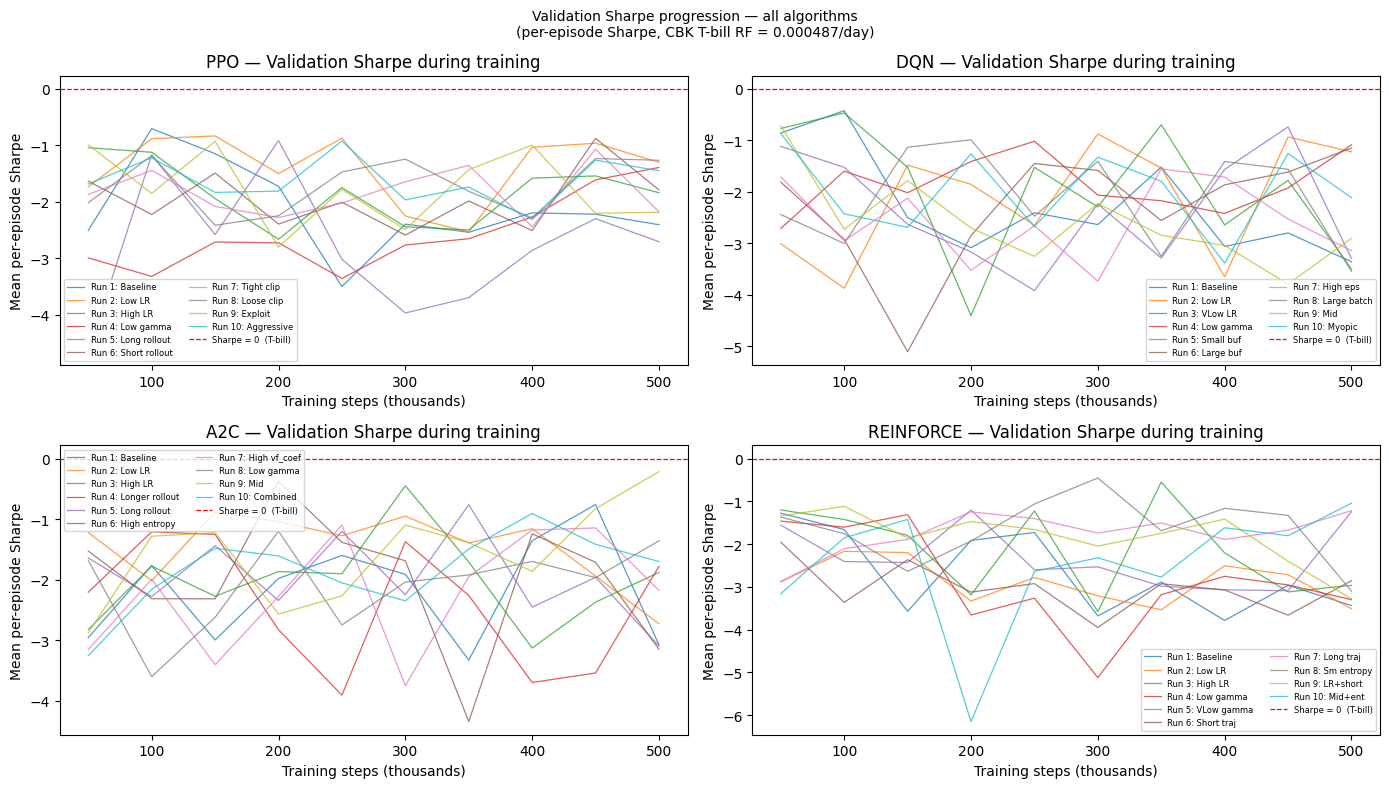

Saved: plots/sharpe_training_progression.png


In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
algo_data = [
    ("PPO",       ppo_results),
    ("DQN",       dqn_results),
    ("A2C",       a2c_results),
    ("REINFORCE", rf_results),
]

for ax, (algo, results) in zip(axes.flatten(), algo_data):
    for r in results:
        if r.get("sharpe_history"):
            steps = [s / 1000 for s in r["sharpe_steps"]]
            ax.plot(steps, r["sharpe_history"],
                    lw=0.9, alpha=0.75,
                    label=f"Run {r['run']}: {r['note']}")
    ax.axhline(0, color="red", lw=0.9, ls="--", label="Sharpe = 0  (T-bill)")
    ax.set_title(f"{algo} — Validation Sharpe during training")
    ax.set_xlabel("Training steps (thousands)")
    ax.set_ylabel("Mean per-episode Sharpe")
    ax.legend(fontsize=6, ncol=2)

plt.suptitle(
    "Validation Sharpe progression — all algorithms\n"
    "(per-episode Sharpe, CBK T-bill RF = 0.000487/day)",
    fontsize=10
)
plt.tight_layout()
plt.savefig("plots/sharpe_training_progression.png", dpi=130, bbox_inches="tight")
plt.show()
print("Saved: plots/sharpe_training_progression.png")

## Plot 2 — Episode reward learning curves

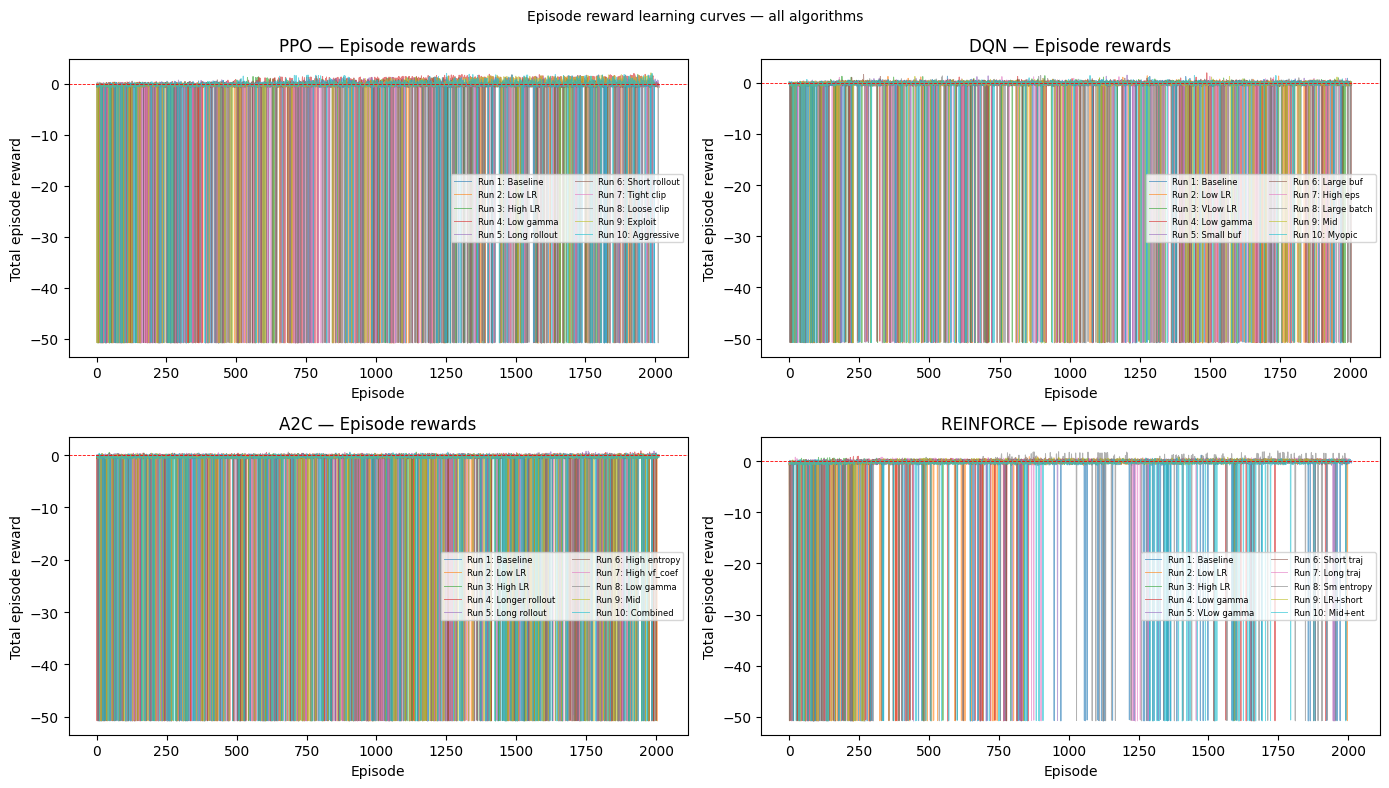

Saved: plots/reward_learning_curves.png

Training complete. Open evaluation/03_backtest.ipynb next.


In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for ax, (algo, results) in zip(axes.flatten(), algo_data):
    for r in results:
        if r.get("episode_rewards"):
            ax.plot(r["episode_rewards"], lw=0.7, alpha=0.6,
                    label=f"Run {r['run']}: {r['note']}")
    ax.axhline(0, color="red", lw=0.6, ls="--")
    ax.set_title(f"{algo} — Episode rewards")
    ax.set_xlabel("Episode")
    ax.set_ylabel("Total episode reward")
    ax.legend(fontsize=6, ncol=2)

plt.suptitle("Episode reward learning curves — all algorithms", fontsize=10)
plt.tight_layout()
plt.savefig("plots/reward_learning_curves.png", dpi=130, bbox_inches="tight")
plt.show()
print("Saved: plots/reward_learning_curves.png")
print("\nTraining complete. Open evaluation/03_backtest.ipynb next.")

In [20]:
import json, os

# Save full results from the in-memory variables that still exist
# from the training session — no retraining needed

os.makedirs("models/ppo",       exist_ok=True)
os.makedirs("models/dqn",       exist_ok=True)
os.makedirs("models/a2c",       exist_ok=True)
os.makedirs("models/reinforce", exist_ok=True)

with open("models/ppo/ppo_results_full.json", "w") as f:
    json.dump(ppo_results, f, indent=2)
print(f"PPO saved — {len(ppo_results)} runs, "
      f"episode_rewards={len(ppo_results[0].get('episode_rewards',[]))} values, "
      f"sharpe_history={len(ppo_results[0].get('sharpe_history',[]))} values")

with open("models/dqn/dqn_results_full.json", "w") as f:
    json.dump(dqn_results, f, indent=2)
print(f"DQN saved — {len(dqn_results)} runs, "
      f"episode_rewards={len(dqn_results[0].get('episode_rewards',[]))} values, "
      f"sharpe_history={len(dqn_results[0].get('sharpe_history',[]))} values")

with open("models/a2c/a2c_results_full.json", "w") as f:
    json.dump(a2c_results, f, indent=2)
print(f"A2C saved — {len(a2c_results)} runs, "
      f"episode_rewards={len(a2c_results[0].get('episode_rewards',[]))} values, "
      f"sharpe_history={len(a2c_results[0].get('sharpe_history',[]))} values")

with open("models/reinforce/reinforce_results_full.json", "w") as f:
    json.dump(rf_results, f, indent=2)
print(f"REINFORCE saved — {len(rf_results)} runs, "
      f"episode_rewards={len(rf_results[0].get('episode_rewards',[]))} values, "
      f"sharpe_history={len(rf_results[0].get('sharpe_history',[]))} values")

print("\nAll full results saved. Now run the load_results fix and plotting cells.")

PPO saved — 10 runs, episode_rewards=2009 values, sharpe_history=10 values
DQN saved — 10 runs, episode_rewards=2000 values, sharpe_history=10 values
A2C saved — 10 runs, episode_rewards=2005 values, sharpe_history=10 values
REINFORCE saved — 10 runs, episode_rewards=2014 values, sharpe_history=10 values

All full results saved. Now run the load_results fix and plotting cells.


In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

#  Load saved results 
def load_results(algo):
    full_path = f"models/{algo}/{algo}_results_full.json"
    slim_path = f"models/{algo}/{algo}_results.json"

    if Path(full_path).exists():
        with open(full_path) as f:
            results = json.load(f)
        r0 = results[0]
        has_r = len(r0.get("episode_rewards", [])) > 0
        has_s = len(r0.get("sharpe_history",  [])) > 0
        print(f"  {algo}: full results loaded  "
              f"episode_rewards={has_r}  sharpe_history={has_s}")
        return results
    elif Path(slim_path).exists():
        with open(slim_path) as f:
            results = json.load(f)
        print(f"  {algo}: slim results loaded — plots will show No data")
        return results
    else:
        print(f"  {algo}: no results file found")
        return None
def smooth(values, window=5):
    """Simple moving average to reduce noise in reward curves."""
    if len(values) < window:
        return values
    result = []
    for i in range(len(values)):
        start = max(0, i - window + 1)
        result.append(np.mean(values[start:i+1]))
    return result

ALGOS = ["ppo", "dqn", "a2c", "reinforce"]
all_results = {a: load_results(a) for a in ALGOS}
all_results = {a: r for a, r in all_results.items() if r is not None}
print(f"Loaded results for: {list(all_results.keys())}")

Loaded results for: ['ppo', 'dqn', 'a2c', 'reinforce']


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that 

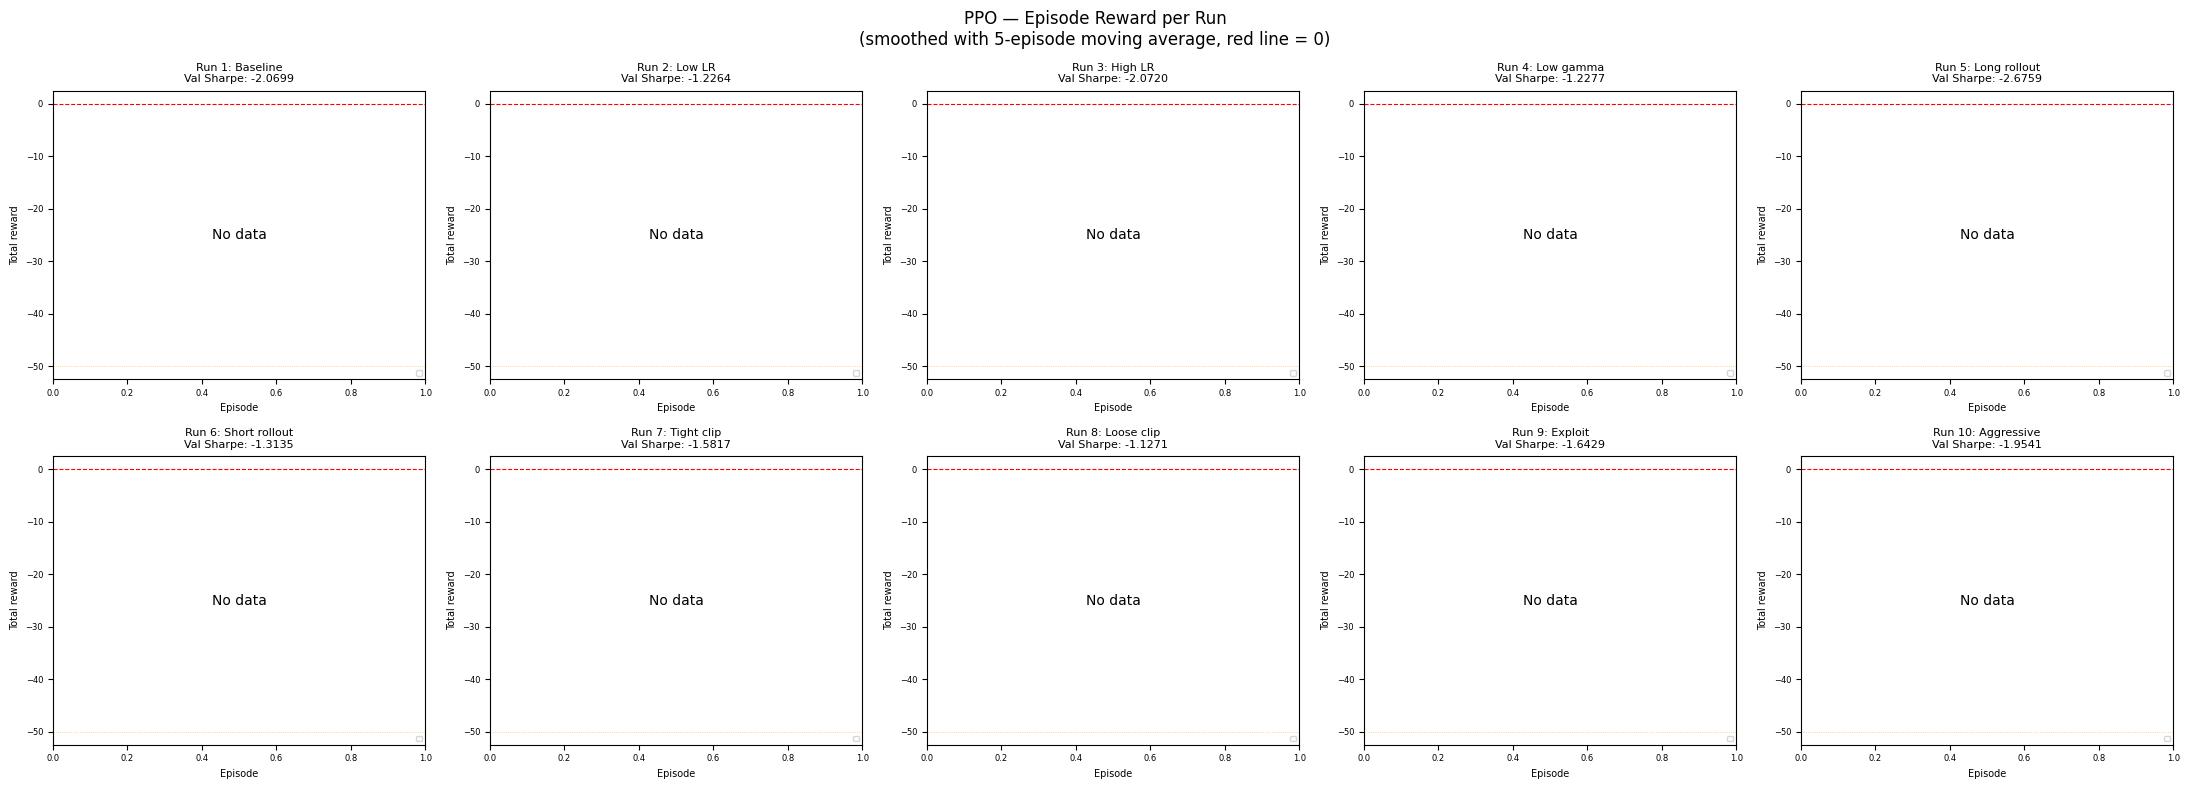

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that 

Saved: plots/ppo_reward_per_run.png


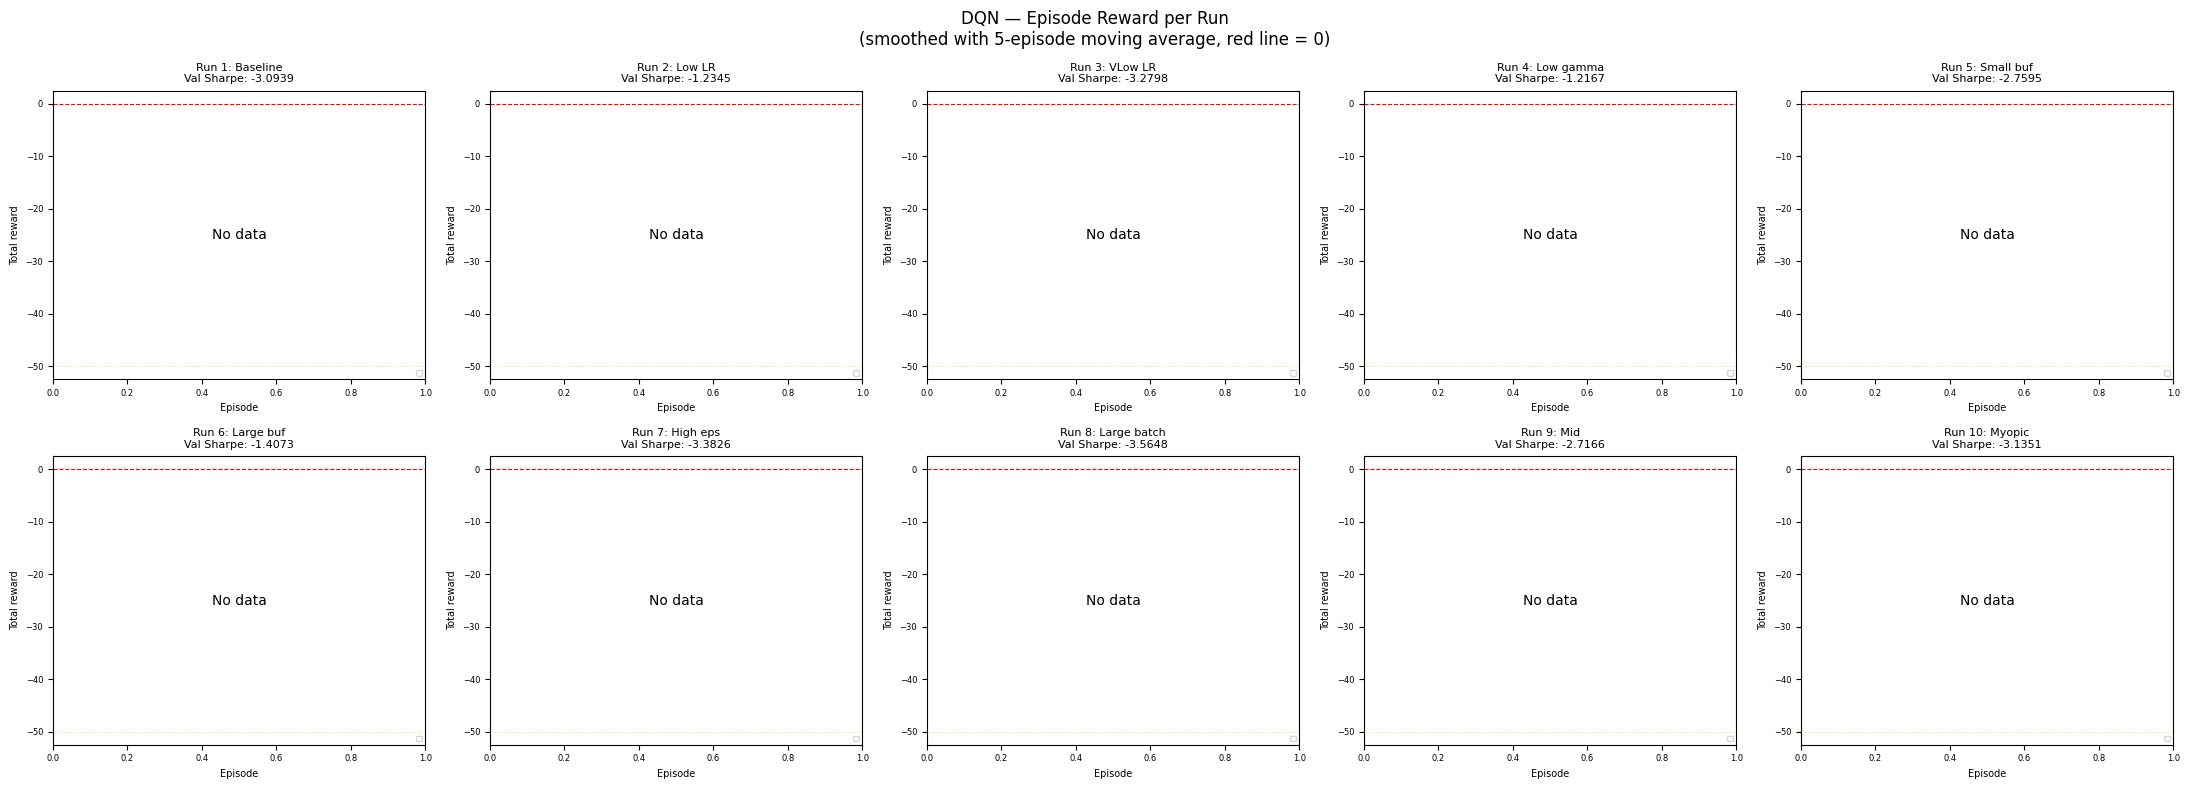

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that 

Saved: plots/dqn_reward_per_run.png


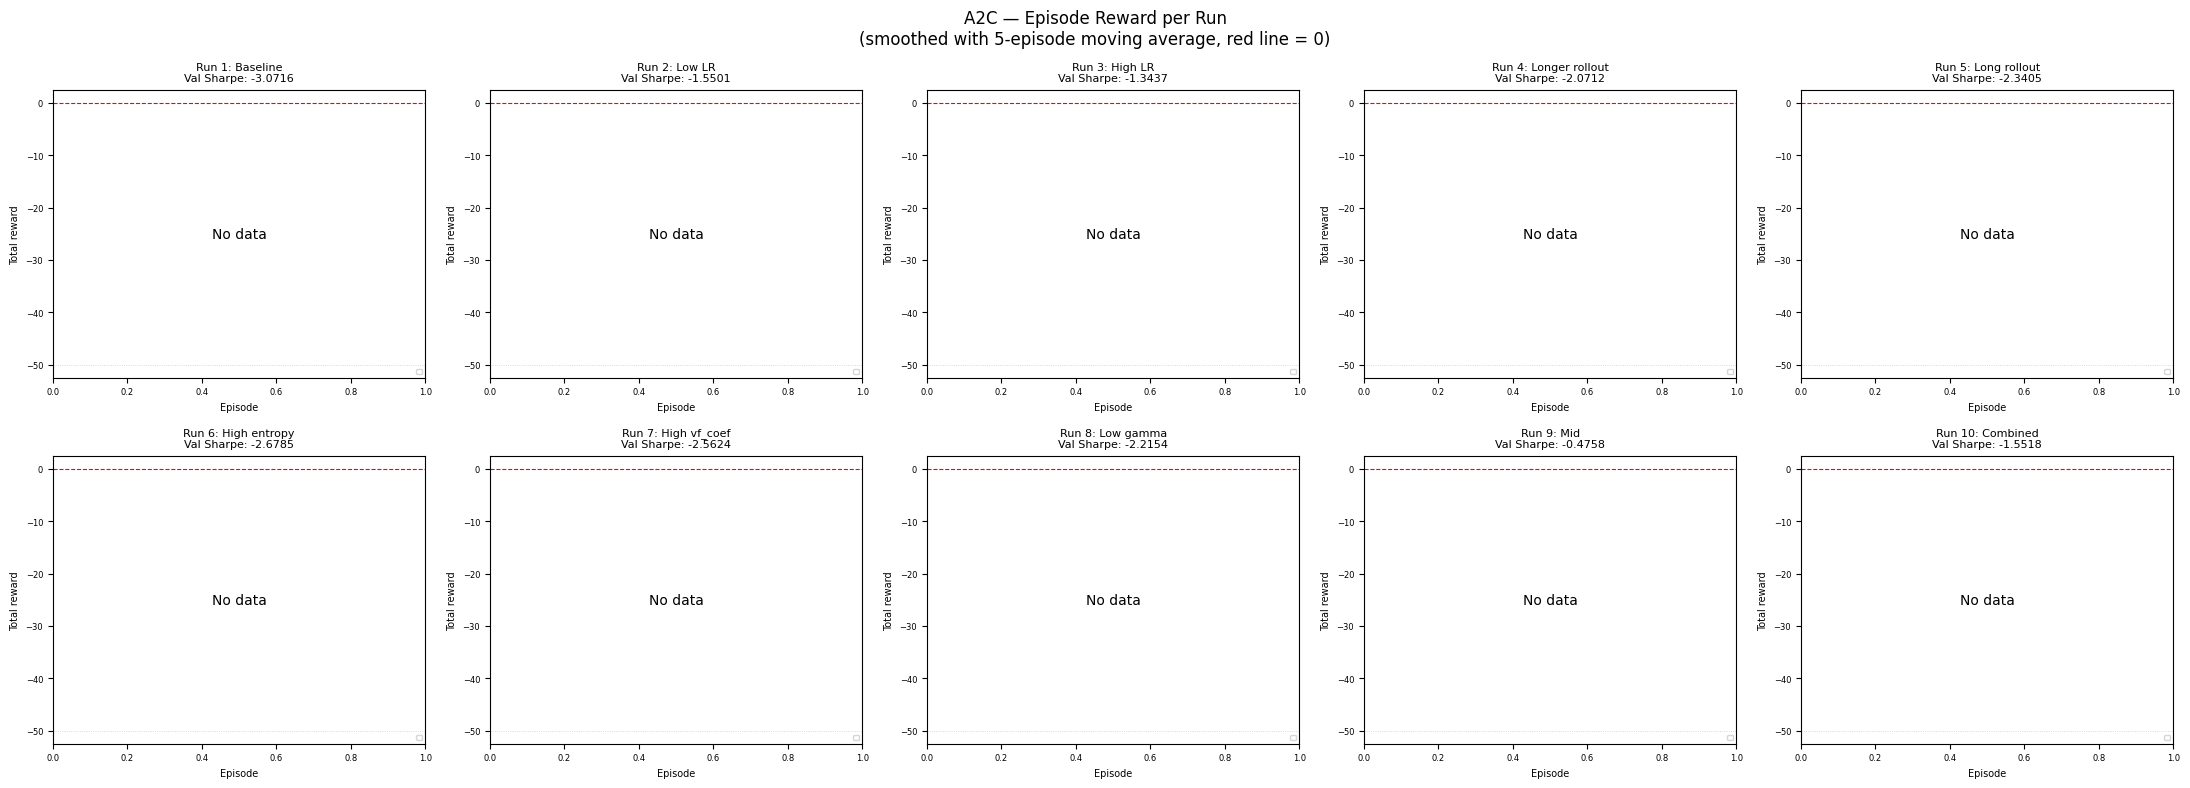

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that 

Saved: plots/a2c_reward_per_run.png


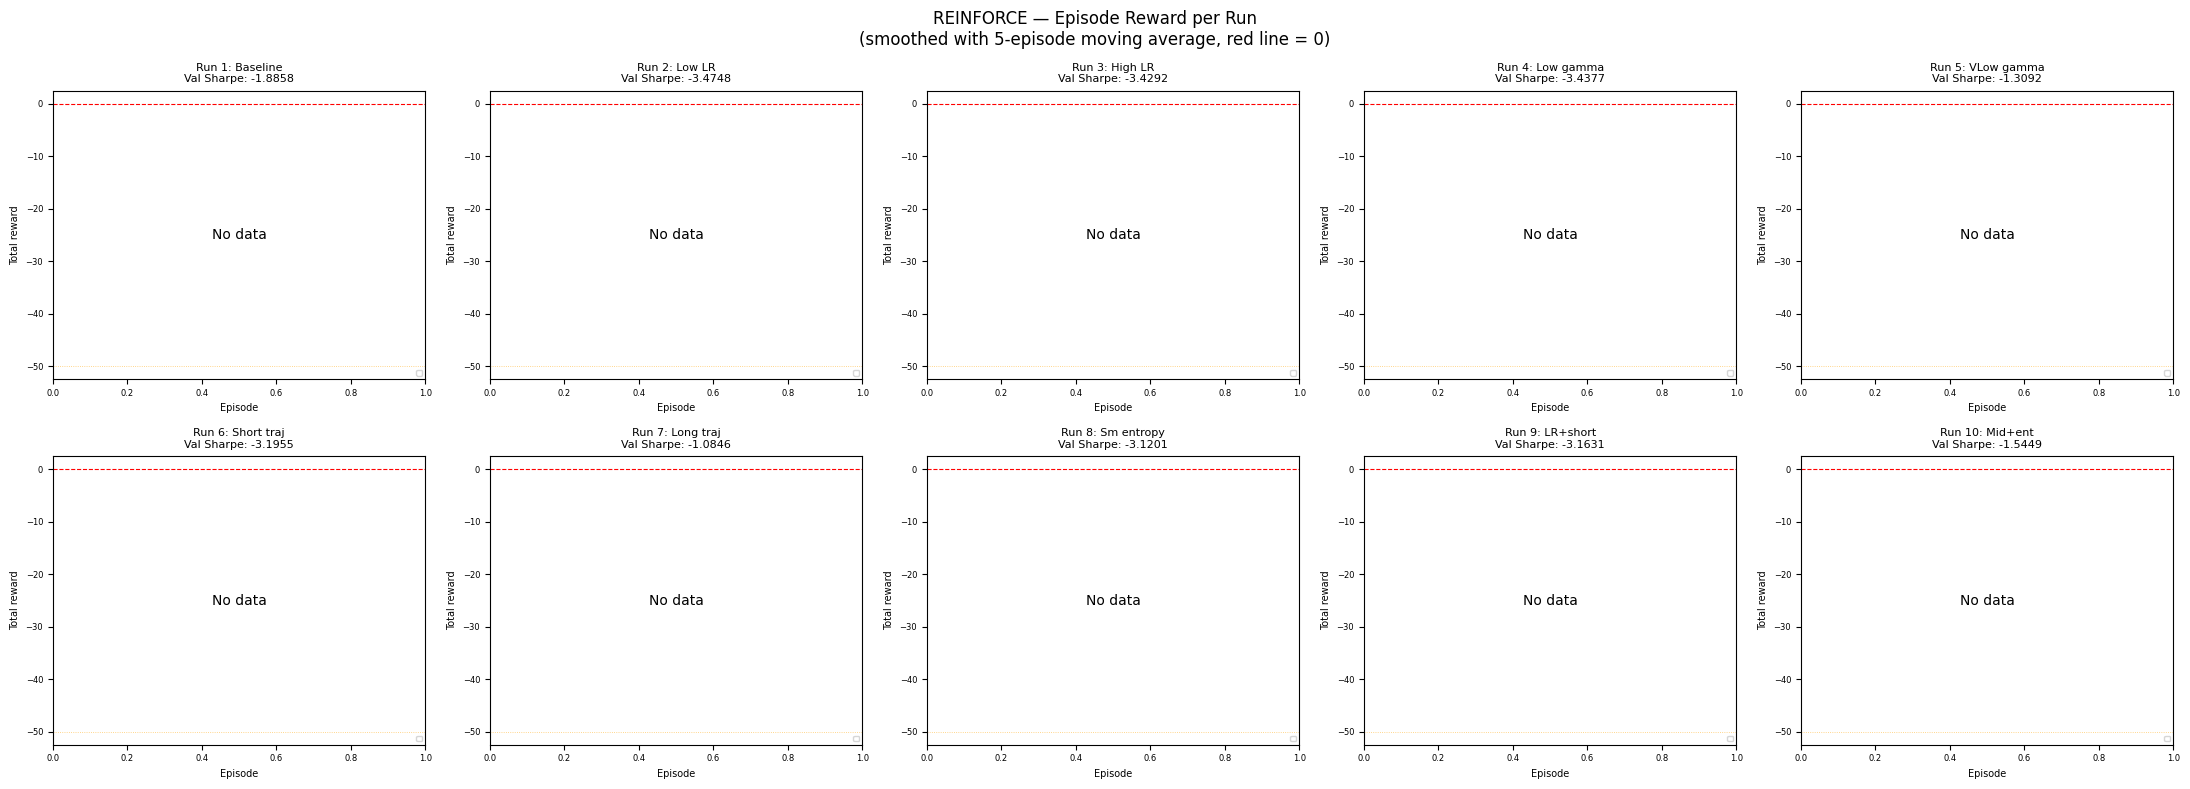

Saved: plots/reinforce_reward_per_run.png


In [16]:
# ── Plot 1: Individual reward curves — one subplot per run ────────────────────
for algo, results in all_results.items():
    fig, axes = plt.subplots(2, 5, figsize=(22, 8))
    axes = axes.flatten()
    fig.suptitle(
        f"{algo.upper()} — Episode Reward per Run\n"
        f"(smoothed with 5-episode moving average, red line = 0)",
        fontsize=12
    )

    for i, r in enumerate(results):
        ax  = axes[i]
        raw = r.get("episode_rewards", [])

        if raw:
            ax.plot(raw, color="lightblue", lw=0.4, alpha=0.6, label="Raw")
            ax.plot(smooth(raw, window=10), color="steelblue", lw=1.2, label="Smoothed")
        else:
            ax.text(0.5, 0.5, "No data", ha="center", va="center",
                    transform=ax.transAxes, fontsize=10)

        ax.axhline(0, color="red", lw=0.8, ls="--")
        ax.axhline(-50, color="orange", lw=0.6, ls=":", alpha=0.6)
        ax.set_title(
            f"Run {r['run']}: {r.get('note','')}\n"
            f"Val Sharpe: {r.get('val_sharpe', 'N/A'):+.4f}",
            fontsize=8
        )
        ax.set_xlabel("Episode", fontsize=7)
        ax.set_ylabel("Total reward", fontsize=7)
        ax.tick_params(labelsize=6)
        ax.legend(fontsize=5, loc="lower right")

    plt.tight_layout()
    path = f"plots/{algo}_reward_per_run.png"
    plt.savefig(path, dpi=130, bbox_inches="tight")
    plt.show()
    print(f"Saved: {path}")

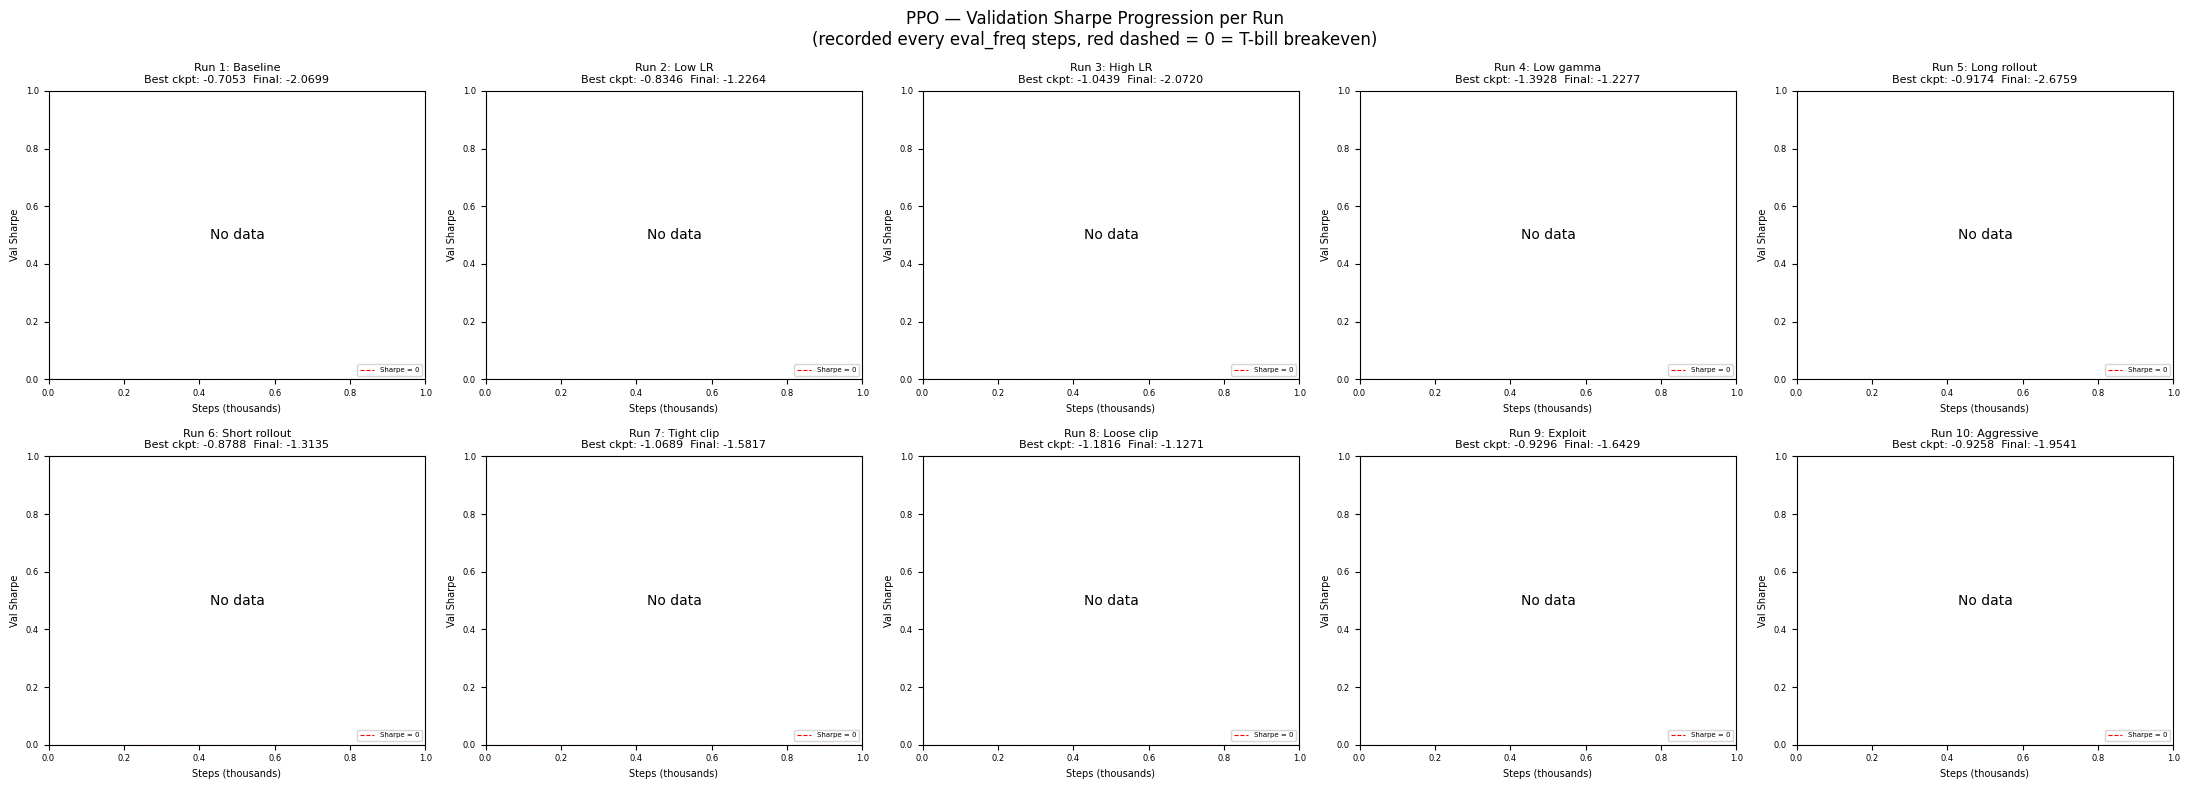

Saved: plots/ppo_sharpe_per_run.png


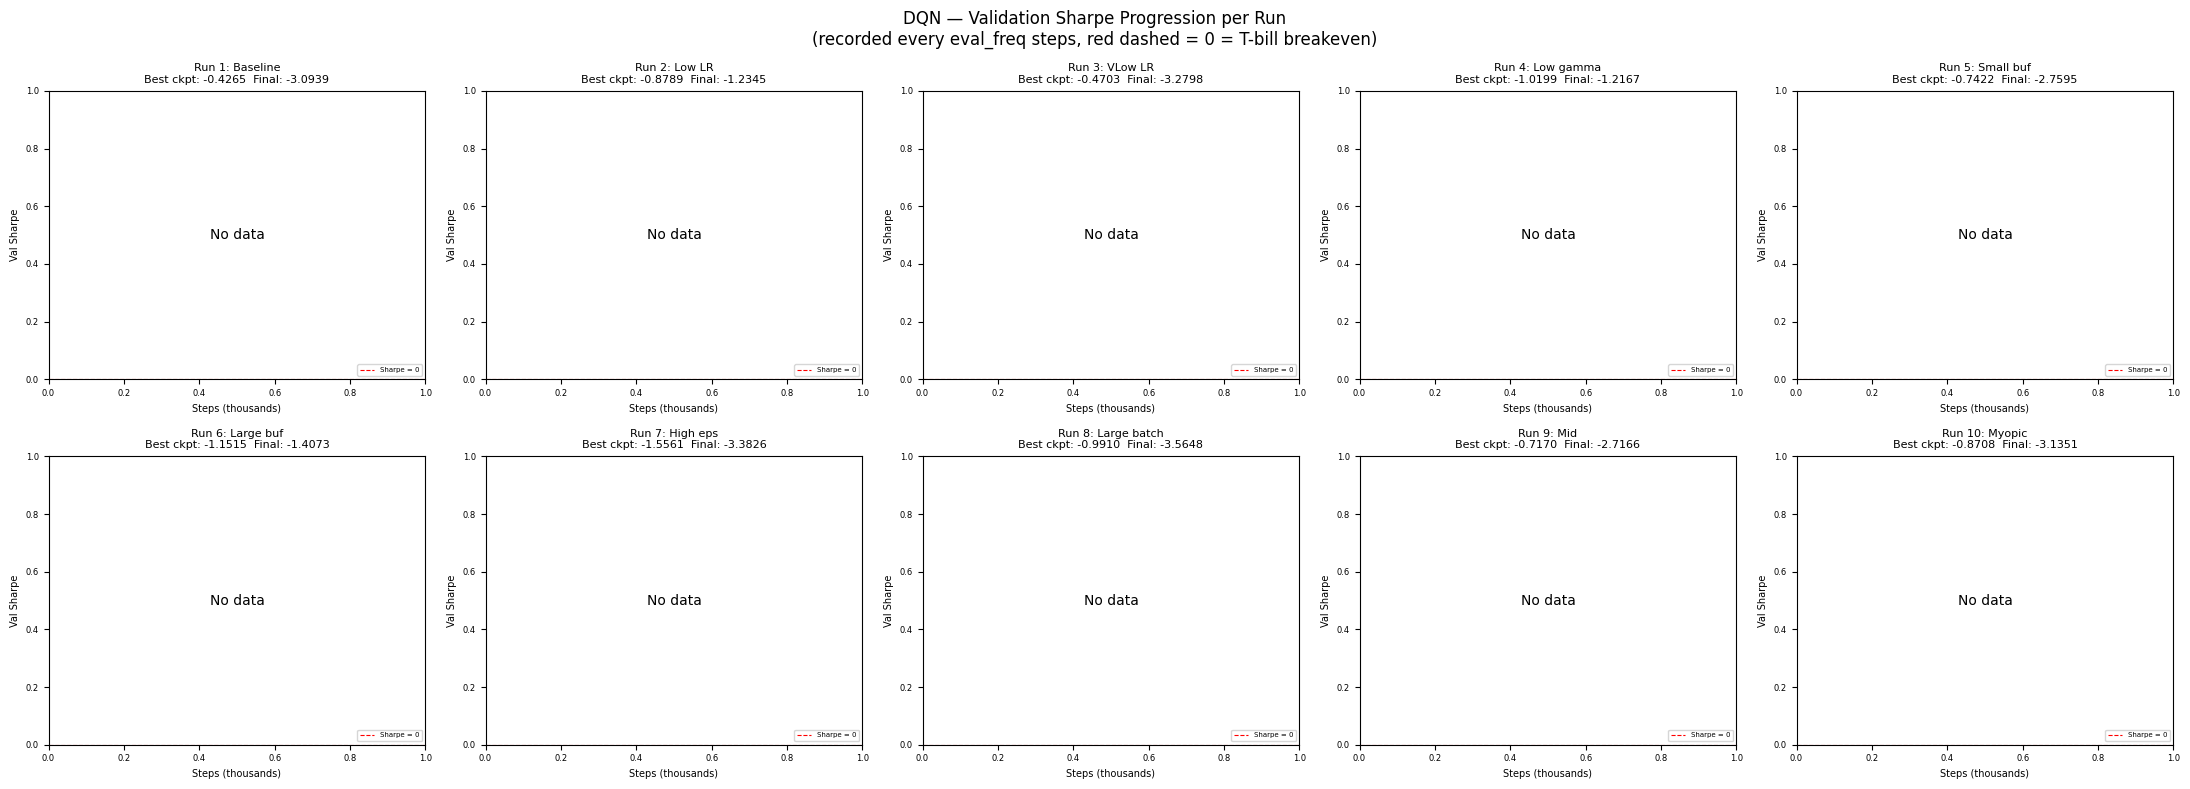

Saved: plots/dqn_sharpe_per_run.png


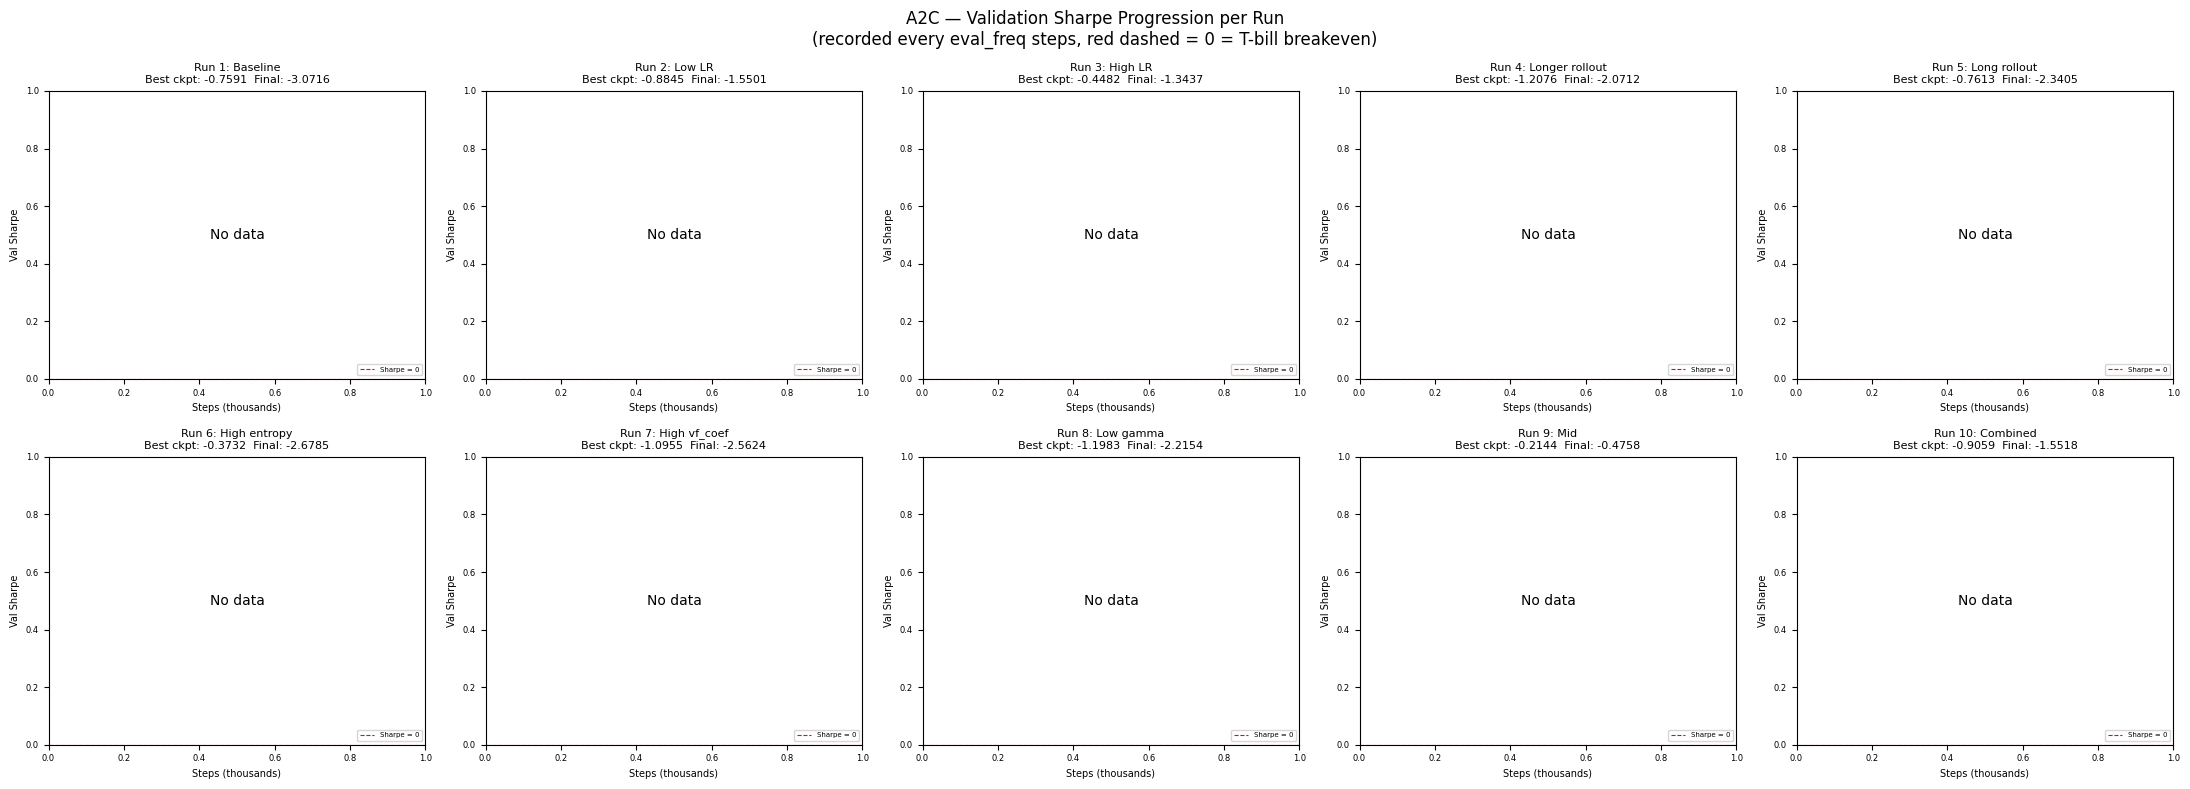

Saved: plots/a2c_sharpe_per_run.png


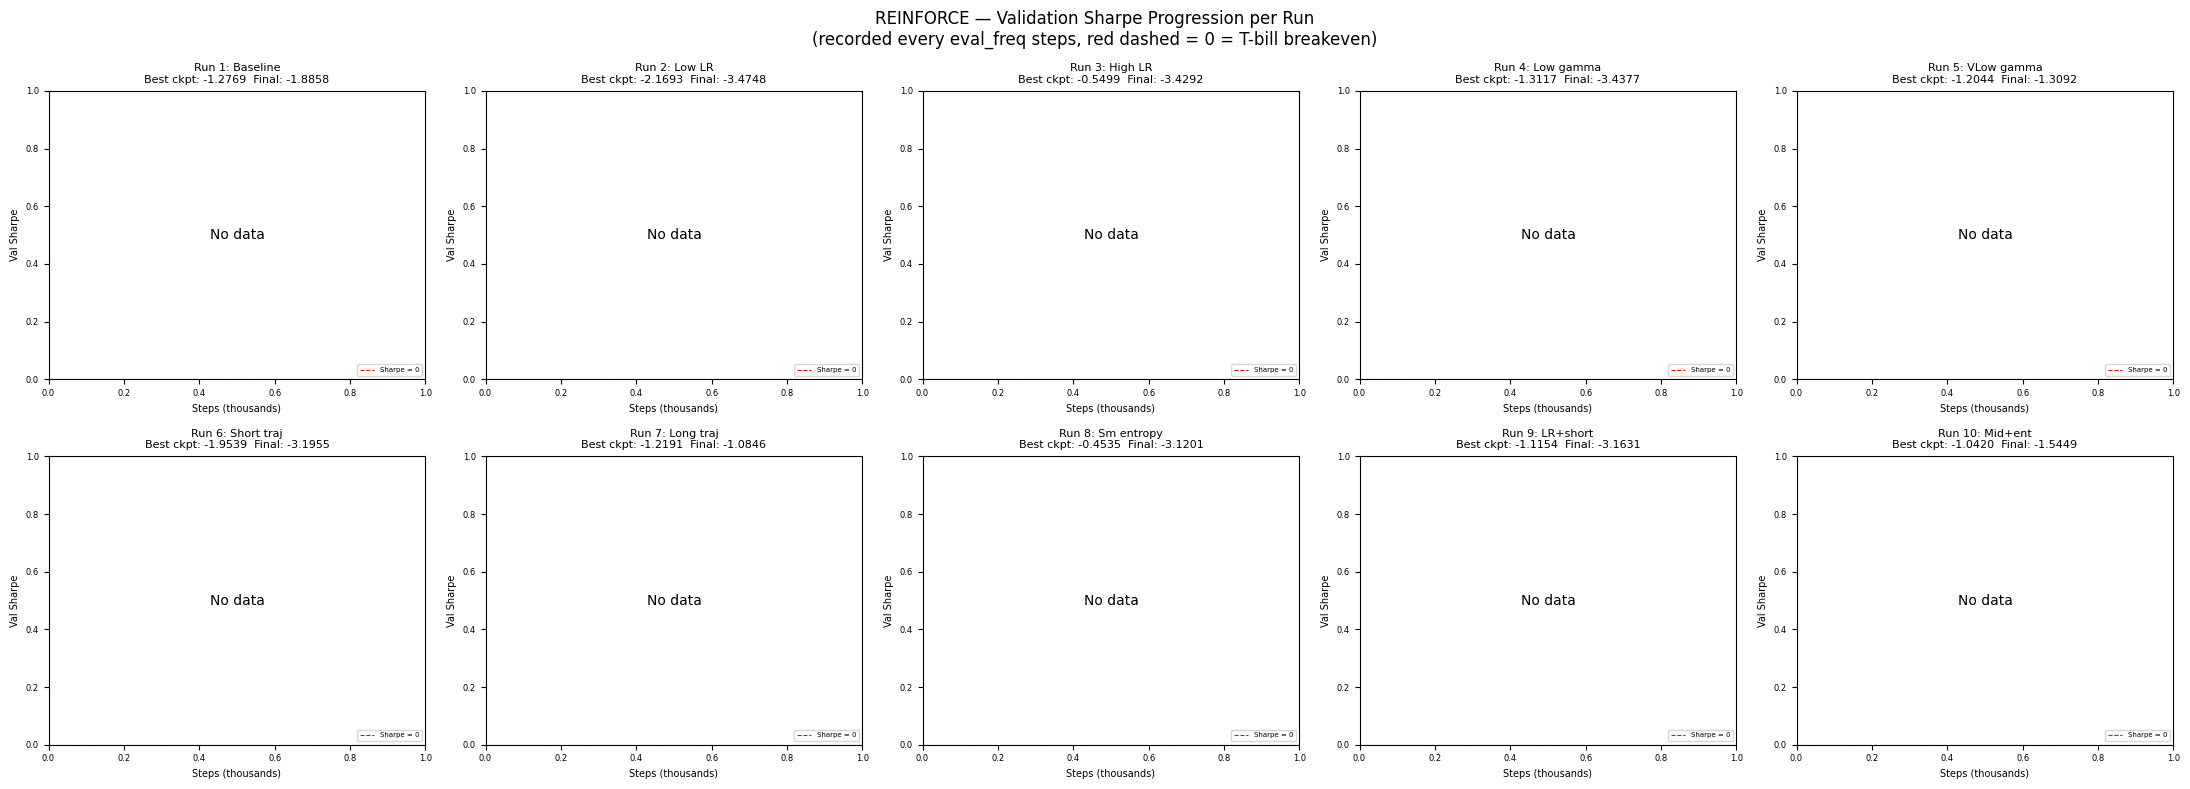

Saved: plots/reinforce_sharpe_per_run.png


In [17]:
# ── Plot 2: Sharpe progression — one subplot per run ─────────────────────────
for algo, results in all_results.items():
    fig, axes = plt.subplots(2, 5, figsize=(22, 8))
    axes = axes.flatten()
    fig.suptitle(
        f"{algo.upper()} — Validation Sharpe Progression per Run\n"
        f"(recorded every eval_freq steps, red dashed = 0 = T-bill breakeven)",
        fontsize=12
    )

    for i, r in enumerate(results):
        ax   = axes[i]
        sh   = r.get("sharpe_history", [])
        steps= r.get("sharpe_steps",   [])

        if sh and steps:
            steps_k = [s / 1000 for s in steps]
            ax.plot(steps_k, sh, color="darkorange", lw=1.2, marker="o",
                    markersize=3, label="Val Sharpe")
            # Mark the best checkpoint
            best_idx = int(np.argmax(sh))
            ax.scatter(steps_k[best_idx], sh[best_idx],
                       color="green", s=60, zorder=5,
                       label=f"Best: {sh[best_idx]:+.3f}")
        else:
            ax.text(0.5, 0.5, "No data", ha="center", va="center",
                    transform=ax.transAxes, fontsize=10)

        ax.axhline(0, color="red", lw=0.8, ls="--", label="Sharpe = 0")
        ax.set_title(
            f"Run {r['run']}: {r.get('note','')}\n"
            f"Best ckpt: {r.get('best_ckpt_sharpe', 'N/A'):+.4f}  "
            f"Final: {r.get('val_sharpe', 'N/A'):+.4f}",
            fontsize=8
        )
        ax.set_xlabel("Steps (thousands)", fontsize=7)
        ax.set_ylabel("Val Sharpe", fontsize=7)
        ax.tick_params(labelsize=6)
        ax.legend(fontsize=5, loc="lower right")

    plt.tight_layout()
    path = f"plots/{algo}_sharpe_per_run.png"
    plt.savefig(path, dpi=130, bbox_inches="tight")
    plt.show()
    print(f"Saved: {path}")

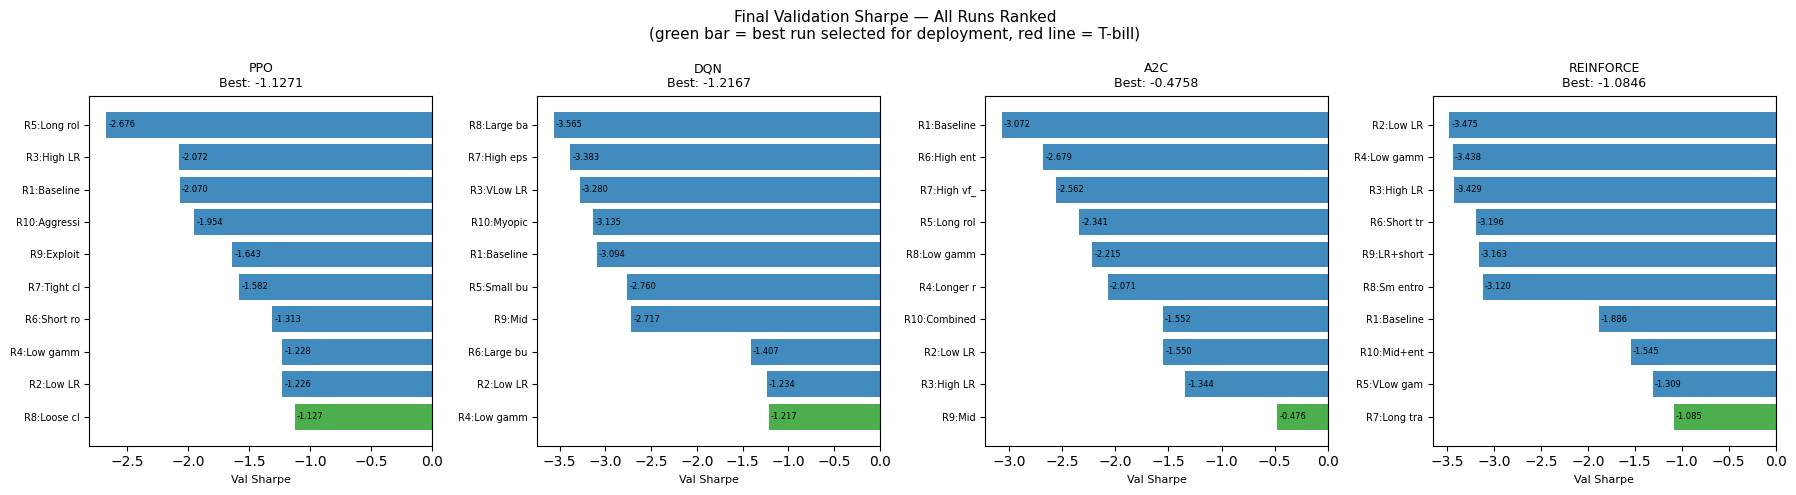

Saved: plots/algorithm_ranking.png


In [18]:
# ── Plot 3: Algorithm ranking by final validation Sharpe ──────────────────────
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle(
    "Final Validation Sharpe — All Runs Ranked\n"
    "(green bar = best run selected for deployment, red line = T-bill)",
    fontsize=11
)

for ax, (algo, results) in zip(axes, all_results.items()):
    runs   = [r["run"]        for r in results]
    sharpes= [r.get("val_sharpe", -99) for r in results]
    notes  = [r.get("note","") for r in results]

    # Sort by Sharpe descending
    order  = np.argsort(sharpes)[::-1]
    s_sorted = [sharpes[i] for i in order]
    n_sorted = [f"R{runs[i]}:{notes[i][:8]}" for i in order]

    colors = ["#2ca02c" if i == 0 else "#1f77b4" for i in range(len(s_sorted))]
    bars   = ax.barh(range(len(s_sorted)), s_sorted, color=colors, alpha=0.85)
    ax.set_yticks(range(len(s_sorted)))
    ax.set_yticklabels(n_sorted, fontsize=7)
    ax.axvline(0, color="red", lw=0.8, ls="--")
    ax.set_title(f"{algo.upper()}\nBest: {s_sorted[0]:+.4f}", fontsize=9)
    ax.set_xlabel("Val Sharpe", fontsize=8)

    # Label bars
    for bar, val in zip(bars, s_sorted):
        ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
                f"{val:+.3f}", va="center", fontsize=6)

plt.tight_layout()
plt.savefig("plots/algorithm_ranking.png", dpi=130, bbox_inches="tight")
plt.show()
print("Saved: plots/algorithm_ranking.png")

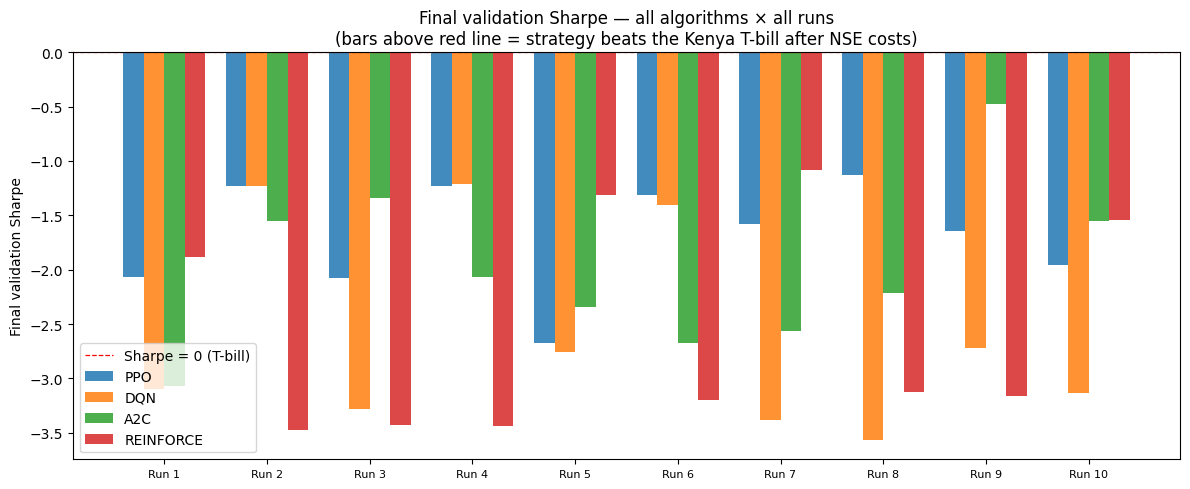

Saved: plots/all_runs_comparison.png


In [19]:
# ── Plot 4: Cross-algorithm Sharpe comparison at end of training ──────────────
fig, ax = plt.subplots(figsize=(12, 5))

x     = np.arange(10)
width = 0.2
colors= ["#1f77b4","#ff7f0e","#2ca02c","#d62728"]

for i, (algo, results) in enumerate(all_results.items()):
    sharpes = [r.get("val_sharpe", -99) for r in sorted(results, key=lambda r: r["run"])]
    ax.bar(x + i * width, sharpes, width, label=algo.upper(),
           color=colors[i], alpha=0.85)

ax.axhline(0, color="red", lw=0.9, ls="--", label="Sharpe = 0 (T-bill)")
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels([f"Run {i+1}" for i in range(10)], fontsize=8)
ax.set_ylabel("Final validation Sharpe")
ax.set_title(
    "Final validation Sharpe — all algorithms × all runs\n"
    "(bars above red line = strategy beats the Kenya T-bill after NSE costs)"
)
ax.legend()
plt.tight_layout()
plt.savefig("plots/all_runs_comparison.png", dpi=130, bbox_inches="tight")
plt.show()
print("Saved: plots/all_runs_comparison.png")